# Round 1 EDA
Products: `ASH_COATED_OSMIUM`, `INTARIAN_PEPPER_ROOT`  
3 days of data: day -2, -1, 0

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

DATA = '/Users/markiejr/Propserity_4/data/ROUND1'

# Load all 3 days of price data
price_dfs = []
for day in [-2, -1, 0]:
    df = pd.read_csv(f'{DATA}/prices_round_1_day_{day}.csv', sep=';')
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)

# Recompute mid_price cleanly from best bid/ask where available
prices['mid_price_clean'] = np.where(
    prices['bid_price_1'].notna() & prices['ask_price_1'].notna(),
    (prices['bid_price_1'] + prices['ask_price_1']) / 2,
    np.where(prices['bid_price_1'].notna(), prices['bid_price_1'],
    np.where(prices['ask_price_1'].notna(), prices['ask_price_1'], np.nan))
)

# Drop rows with no valid price (both sides empty)
prices = prices[prices['mid_price_clean'].notna() & (prices['mid_price_clean'] > 0)].copy()

# Build a global timestamp (each day = 1_000_000 ticks apart)
prices['global_ts'] = prices['day'].map({-2: 0, -1: 1_000_000, 0: 2_000_000}) + prices['timestamp']

print(f"Rows after cleaning: {prices.shape[0]}")
print(prices.groupby('product')['mid_price_clean'].describe().round(2))
prices.head()

Rows after cleaning: 59897
                        count      mean     std     min      25%      50%  \
product                                                                     
ASH_COATED_OSMIUM     29951.0  10000.20    5.35  9977.0   9997.0  10000.5   
INTARIAN_PEPPER_ROOT  29946.0  11499.89  866.11  9998.5  10750.0  11500.0   

                          75%      max  
product                                 
ASH_COATED_OSMIUM     10003.5  10023.0  
INTARIAN_PEPPER_ROOT  12249.5  13007.0  


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,mid_price_clean,global_ts
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,9998.5,0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,10010.0,0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,10000.5,100
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,10000.0,100
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,10001.5,200


In [12]:
# Load all 3 days of trade data
trade_dfs = []
for day in [-2, -1, 0]:
    df = pd.read_csv(f'{DATA}/trades_round_1_day_{day}.csv', sep=';')
    df['day'] = day
    trade_dfs.append(df)

trades = pd.concat(trade_dfs, ignore_index=True)
trades['global_ts'] = trades['day'].map({-2: 0, -1: 1_000_000, 0: 2_000_000}) + trades['timestamp']

print(trades.shape)
trades.head()

(2276, 9)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_ts
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2,700
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2,900
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2,1000
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2,2500
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2,4000


## Mid-Price Over Time

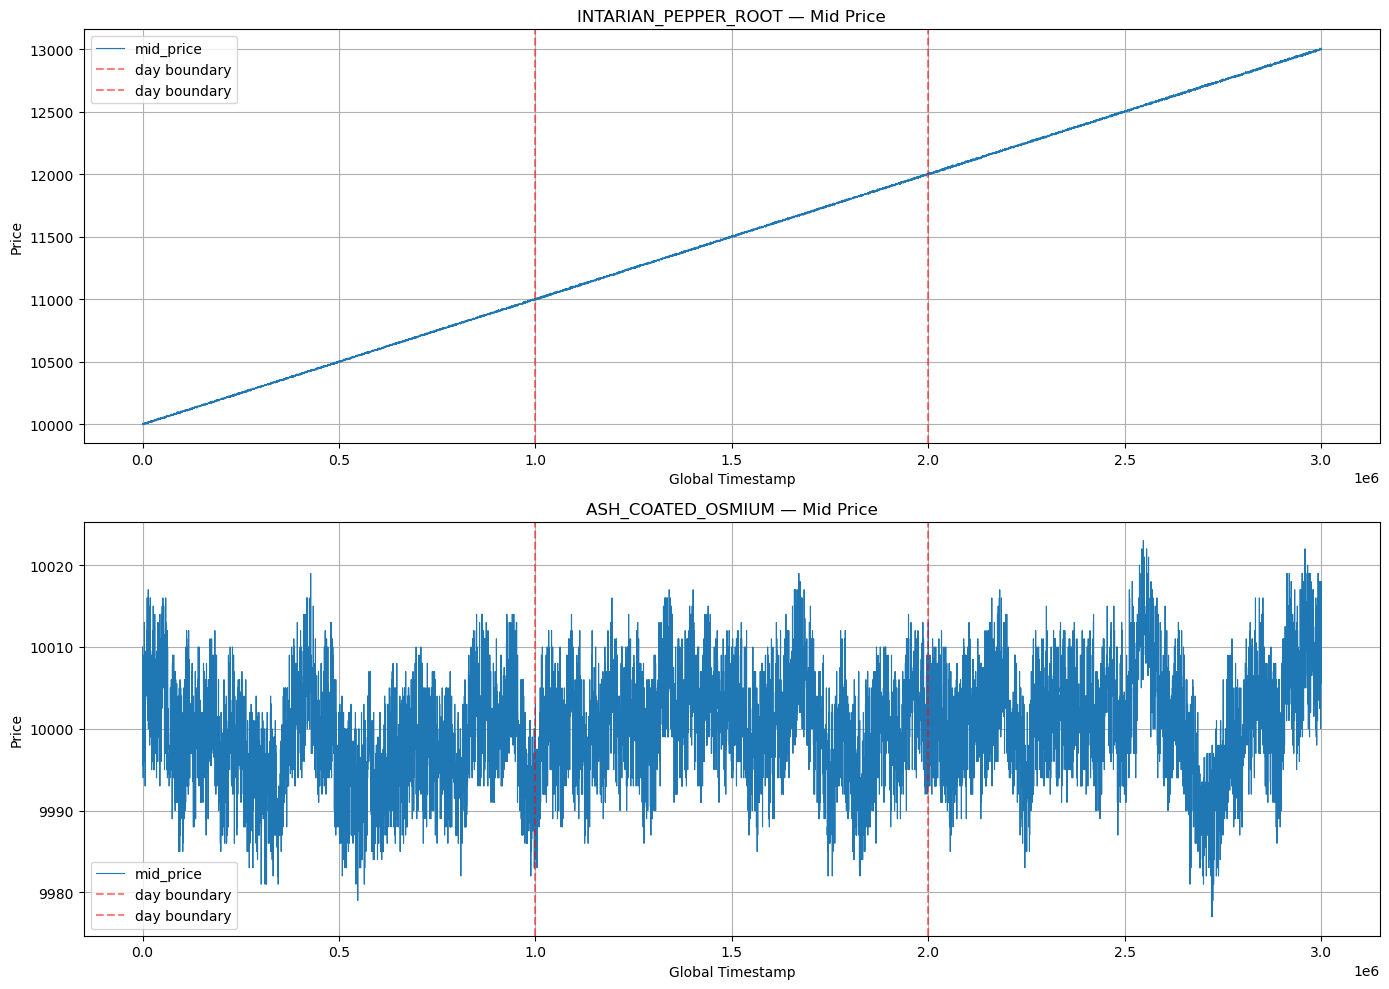

In [13]:
products = prices['product'].unique()

fig, axes = plt.subplots(len(products), 1, figsize=(14, 5 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    df = prices[prices['product'] == product].copy()
    ax.plot(df['global_ts'], df['mid_price_clean'], linewidth=0.8, label='mid_price')
    
    for day_start in [1_000_000, 2_000_000]:
        ax.axvline(day_start, color='red', linestyle='--', alpha=0.5, label='day boundary')
    
    ax.set_title(f'{product} — Mid Price')
    ax.set_xlabel('Global Timestamp')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.show()

## Rolling Statistics & Z-Score (Mean Reversion Signal)

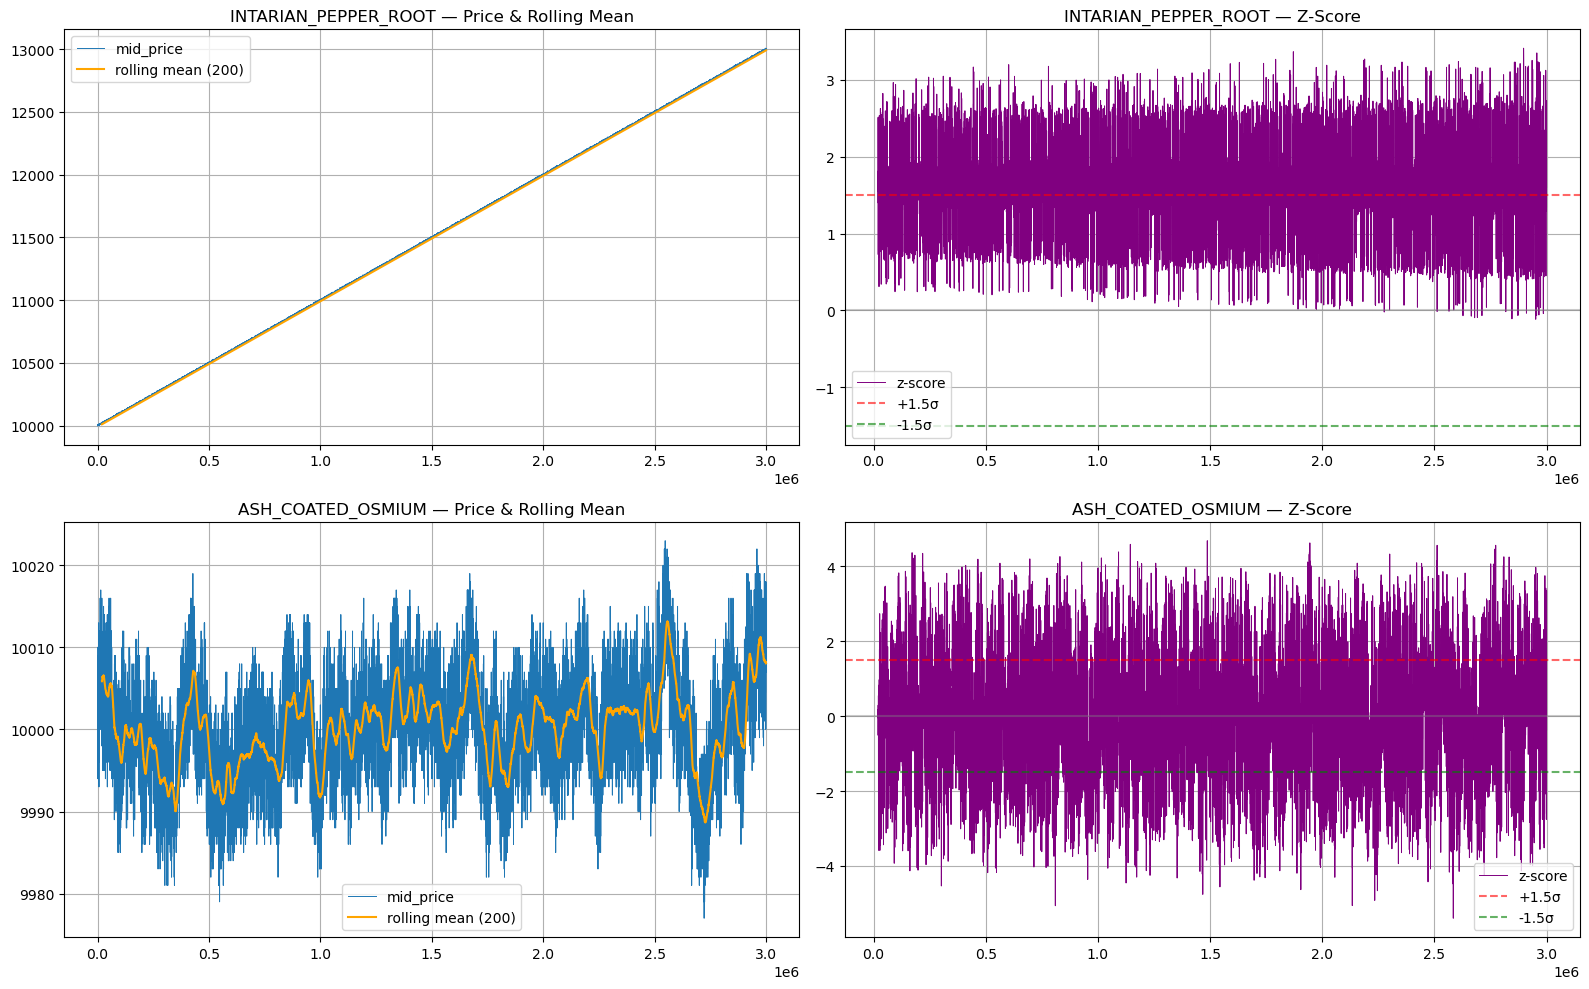

,mean,std,min,max
INTARIAN_PEPPER_ROOT,11499.888549,866.107144,9998.5,13007.0
ASH_COATED_OSMIUM,10000.204234,5.349695,9977.0,10023.0


In [14]:
WINDOW = 200  # ~200 ticks rolling window

fig, axes = plt.subplots(len(products), 2, figsize=(16, 5 * len(products)))
if len(products) == 1:
    axes = [axes]

stats_summary = {}

for i, product in enumerate(products):
    df = prices[prices['product'] == product].copy().reset_index(drop=True)
    
    df['rolling_mean'] = df['mid_price_clean'].rolling(WINDOW).mean()
    df['rolling_std']  = df['mid_price_clean'].rolling(WINDOW).std()
    df['zscore']       = (df['mid_price_clean'] - df['rolling_mean']) / df['rolling_std']

    ax1 = axes[i][0]
    ax1.plot(df['global_ts'], df['mid_price_clean'], linewidth=0.7, label='mid_price')
    ax1.plot(df['global_ts'], df['rolling_mean'], linewidth=1.5, color='orange', label=f'rolling mean ({WINDOW})')
    ax1.set_title(f'{product} — Price & Rolling Mean')
    ax1.legend()

    ax2 = axes[i][1]
    ax2.plot(df['global_ts'], df['zscore'], linewidth=0.7, color='purple', label='z-score')
    ax2.axhline(1.5,  color='red',   linestyle='--', alpha=0.6, label='+1.5σ')
    ax2.axhline(-1.5, color='green', linestyle='--', alpha=0.6, label='-1.5σ')
    ax2.axhline(0,    color='grey',  linestyle='-',  alpha=0.4)
    ax2.set_title(f'{product} — Z-Score')
    ax2.legend()

    stats_summary[product] = {
        'mean': df['mid_price_clean'].mean(),
        'std':  df['mid_price_clean'].std(),
        'min':  df['mid_price_clean'].min(),
        'max':  df['mid_price_clean'].max(),
    }

plt.tight_layout()
plt.show()

pd.DataFrame(stats_summary).T

## Bid-Ask Spread Analysis

INTARIAN_PEPPER_ROOT: mean spread = 13.05, median = 13.00
ASH_COATED_OSMIUM: mean spread = 16.18, median = 16.00


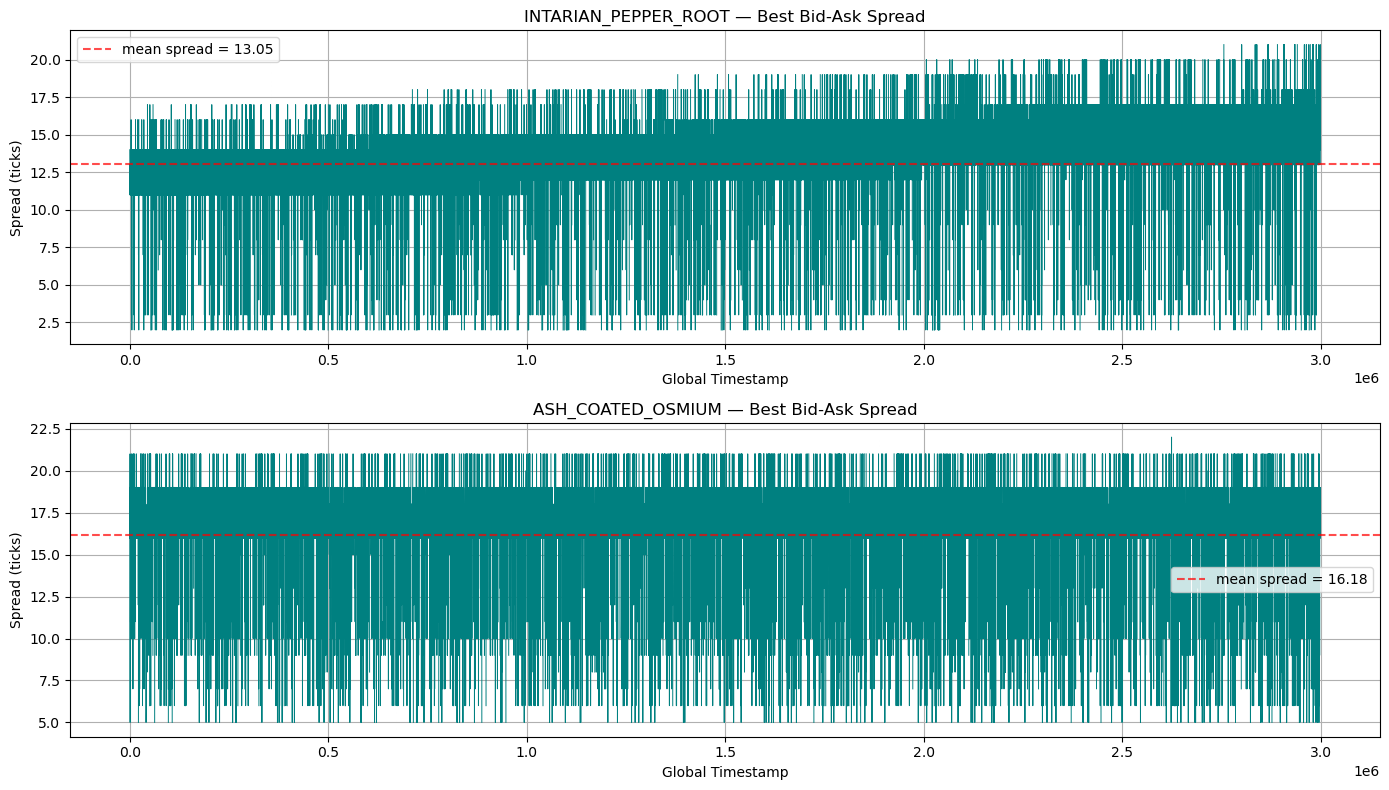

In [15]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    df = prices[prices['product'] == product].copy()
    df['spread'] = df['ask_price_1'] - df['bid_price_1']
    
    ax.plot(df['global_ts'], df['spread'], linewidth=0.7, color='teal')
    ax.set_title(f'{product} — Best Bid-Ask Spread')
    ax.set_ylabel('Spread (ticks)')
    ax.set_xlabel('Global Timestamp')
    
    mean_spread = df['spread'].mean()
    ax.axhline(mean_spread, color='red', linestyle='--', alpha=0.7, label=f'mean spread = {mean_spread:.2f}')
    ax.legend()
    print(f"{product}: mean spread = {mean_spread:.2f}, median = {df['spread'].median():.2f}")

plt.tight_layout()
plt.show()

## Order Book Imbalance (Buy vs Sell Pressure)

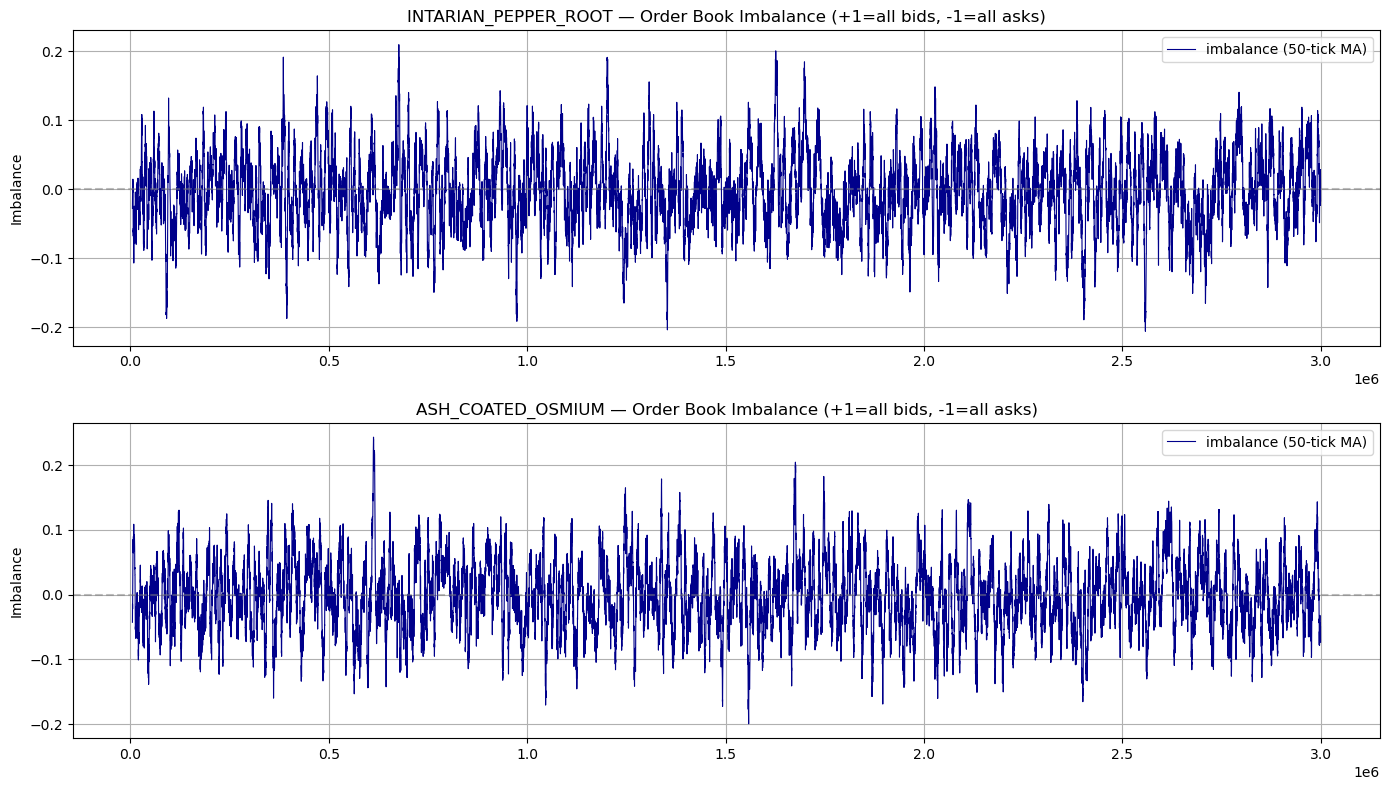

In [16]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    df = prices[prices['product'] == product].copy()

    bid_vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
    ask_vol_cols = ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']

    df['total_bid_vol'] = df[bid_vol_cols].fillna(0).sum(axis=1)
    df['total_ask_vol'] = df[ask_vol_cols].fillna(0).sum(axis=1)
    df['imbalance'] = (df['total_bid_vol'] - df['total_ask_vol']) / (df['total_bid_vol'] + df['total_ask_vol'])

    ax.plot(df['global_ts'], df['imbalance'].rolling(50).mean(), linewidth=0.8, color='darkblue', label='imbalance (50-tick MA)')
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.set_title(f'{product} — Order Book Imbalance (+1=all bids, -1=all asks)')
    ax.set_ylabel('Imbalance')
    ax.legend()

plt.tight_layout()
plt.show()

## Trade Data Analysis

Trade counts per product:
symbol
ASH_COATED_OSMIUM       1265
INTARIAN_PEPPER_ROOT    1011
Name: count, dtype: int64



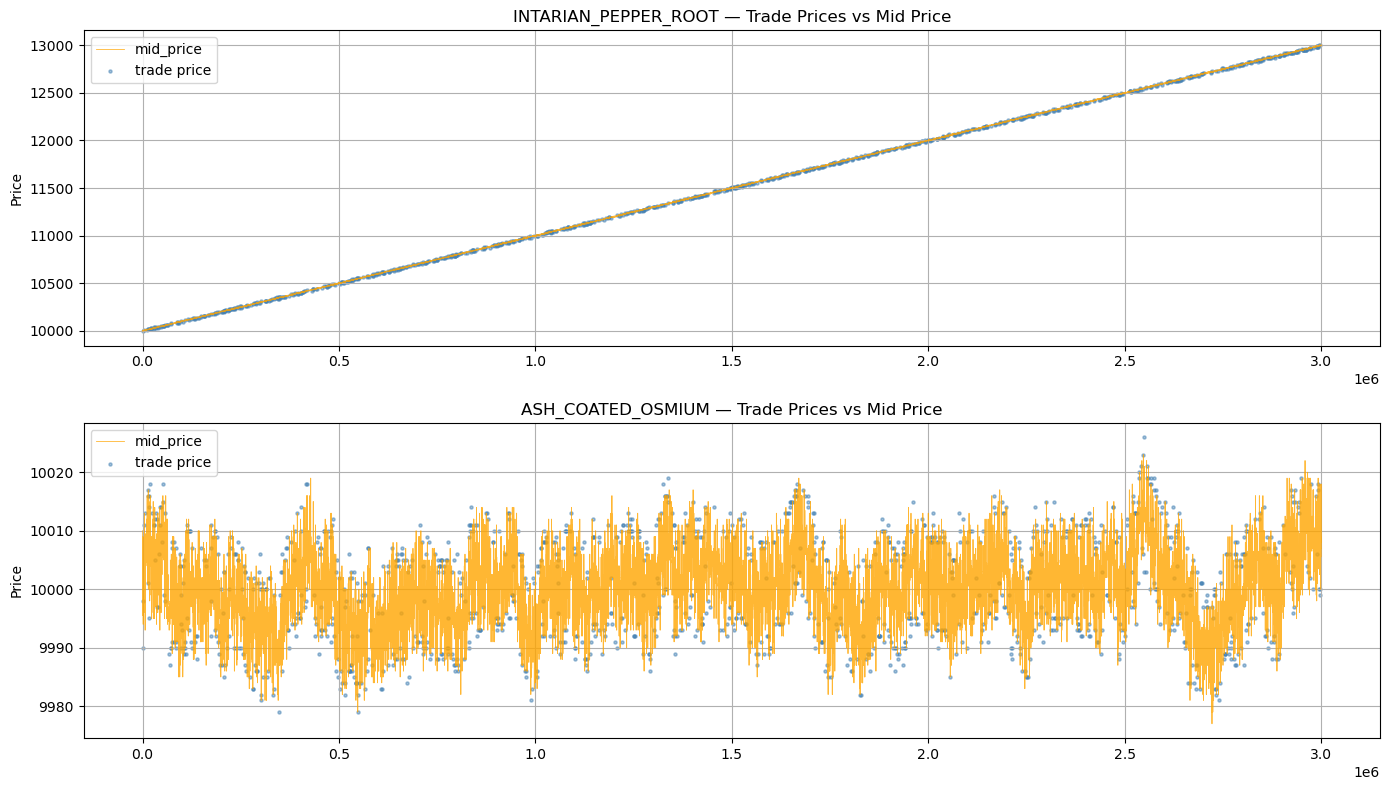

In [17]:
print("Trade counts per product:")
print(trades['symbol'].value_counts())
print()

fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    t = trades[trades['symbol'] == product].copy()
    p = prices[prices['product'] == product]
    
    ax.plot(p['global_ts'], p['mid_price_clean'], linewidth=0.6, color='orange', alpha=0.8, label='mid_price')
    ax.scatter(t['global_ts'], t['price'], s=5, alpha=0.5, color='steelblue', label='trade price')
    
    ax.set_title(f'{product} — Trade Prices vs Mid Price')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.show()

## Price Return Distribution (is it normal? fat-tailed?)

INTARIAN_PEPPER_ROOT: mean_return=0.1002, std=3.1001, kurtosis=2.89, lag-1 autocorr=-0.5006
ASH_COATED_OSMIUM: mean_return=-0.0001, std=3.7272, kurtosis=2.88, lag-1 autocorr=-0.4952


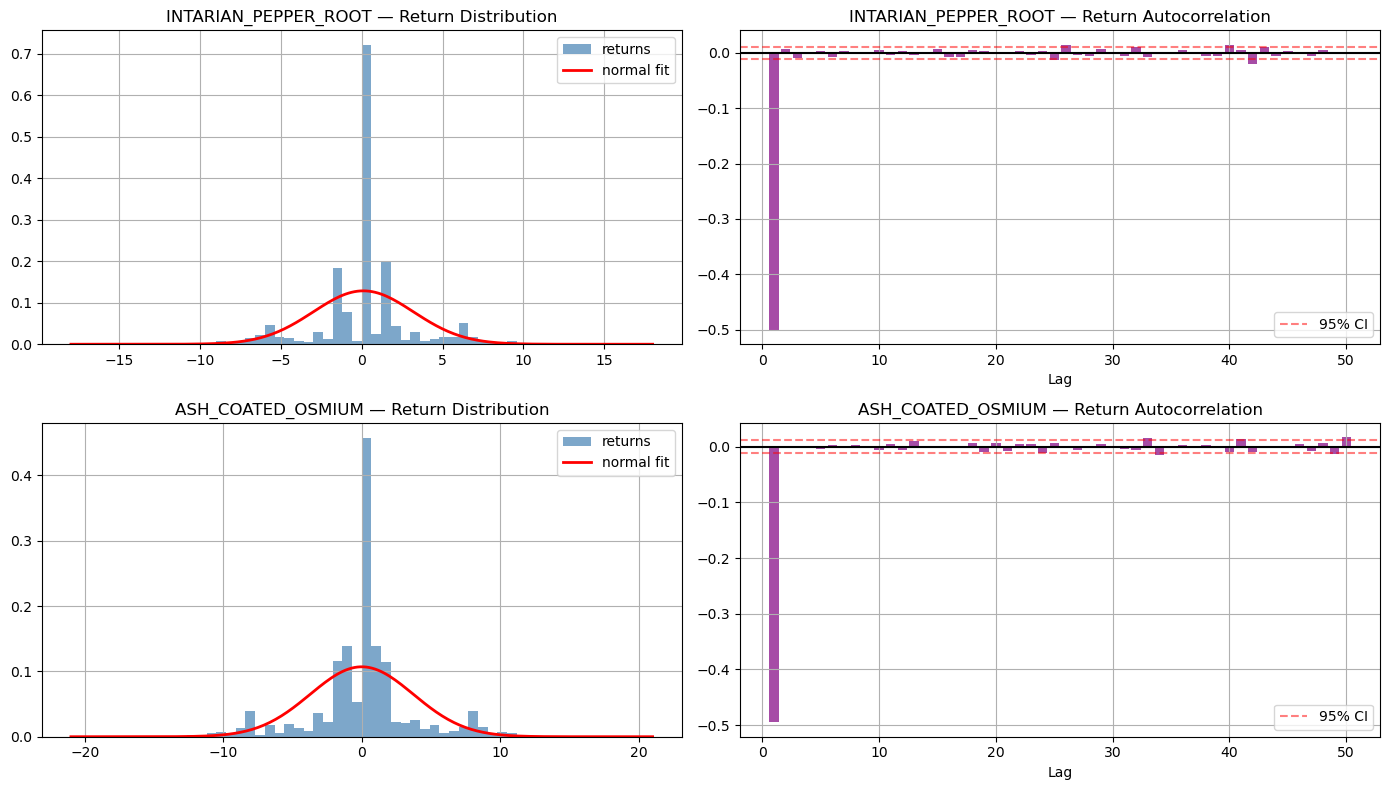

In [18]:
from scipy import stats

fig, axes = plt.subplots(len(products), 2, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for i, product in enumerate(products):
    df = prices[prices['product'] == product].copy()
    df['return'] = df['mid_price_clean'].diff()
    returns = df['return'].dropna()

    ax1 = axes[i][0]
    ax1.hist(returns, bins=60, density=True, color='steelblue', alpha=0.7, label='returns')
    xr = np.linspace(returns.min(), returns.max(), 200)
    ax1.plot(xr, stats.norm.pdf(xr, returns.mean(), returns.std()), 'r-', lw=2, label='normal fit')
    ax1.set_title(f'{product} — Return Distribution')
    ax1.legend()

    ax2 = axes[i][1]
    lags = range(1, 51)
    acf_vals = [returns.autocorr(lag=l) for l in lags]
    ax2.bar(lags, acf_vals, color='purple', alpha=0.7)
    ax2.axhline(0, color='black')
    ax2.axhline(1.96/np.sqrt(len(returns)),  color='red', linestyle='--', alpha=0.5, label='95% CI')
    ax2.axhline(-1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
    ax2.set_title(f'{product} — Return Autocorrelation')
    ax2.set_xlabel('Lag')
    ax2.legend()
    
    kurt = stats.kurtosis(returns)
    print(f"{product}: mean_return={returns.mean():.4f}, std={returns.std():.4f}, kurtosis={kurt:.2f}, lag-1 autocorr={returns.autocorr(1):.4f}")

plt.tight_layout()
plt.show()